# Sumativa 3 - Evaluación y Validación del Modelo
# INFORME FINAL DEL PROYECTO — FASE 4
# EVALUACIÓN Y VALIDACIÓN DEL MODELO
## Proyecto de Machine Learning - Titanic

### Pregunta de investigación

> ¿Es posible predecir si un pasajero del Titanic sobrevivió utilizando las características disponibles al momento del embarque?

### Integrantes
- Pablo Rodríguez
- Luiskar Espinoza
- Henry Moraga

### Dataset

**Titanic**

### Tipo de problema

**Clasificación binaria**

- 0 → No sobrevivió
- 1 → Sobrevivió

## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset Titanic

In [ ]:
from sklearn.datasets import fetch_openml

titanic = fetch_openml(name="titanic", version=1, as_frame=True)

df = titanic.frame

print("Dataset cargado correctamente.")
print("Dimensiones del dataset:", df.shape)

Dataset cargado correctamente.
Dimensiones del dataset: (1309, 14)


## 3. Exploración inicial del dataset

En esta etapa se revisará la estructura general del dataset, los tipos de datos y la presencia de valores faltantes antes de realizar la preparación de los datos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


## 4. Identificación de la variable objetivo y variables disponibles

La variable `survived` será definida como la variable objetivo del modelo, ya que representa si el pasajero sobrevivió o no.

Las restantes variables serán evaluadas como posibles variables predictoras, considerando posteriormente su tipo de dato, valores faltantes, cardinalidad y pertinencia para el problema.

In [ ]:
print("Variable objetivo: survived")
print("\nVariables disponibles:")

for i, columna in enumerate(df.columns, 1):
    print(f"{i}. {columna}")

Variable objetivo: survived

Variables disponibles:
1. pclass
2. survived
3. name
4. sex
5. age
6. sibsp
7. parch
8. ticket
9. fare
10. cabin
11. embarked
12. boat
13. body
14. home.dest


## 5. Distribución de la variable objetivo

Se analizará la distribución de la variable `survived` para conocer la cantidad y proporción de pasajeros que sobrevivieron y que no sobrevivieron.

In [ ]:
print("Cantidad de registros por categoría:")
print(df['survived'].value_counts())

print("\nPorcentaje de registros por categoría:")
print((df['survived'].value_counts(normalize=True) * 100).round(2))

Cantidad de registros por categoría:
survived
0    809
1    500
Name: count, dtype: int64

Porcentaje de registros por categoría:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


## 6. Identificación de variables predictoras

A partir de la variable objetivo `survived`, se consideran inicialmente como variables predictoras todas las demás variables disponibles en el dataset.

Posteriormente se evaluará cada variable según su naturaleza, valores faltantes, cardinalidad y pertinencia para el modelo.

In [ ]:
variables_predictoras = [columna for columna in df.columns if columna != 'survived']

print("Cantidad de variables predictoras:", len(variables_predictoras))
print("\nVariables predictoras:")

for i, variable in enumerate(variables_predictoras, 1):
    print(f"{i}. {variable}")

Cantidad de variables predictoras: 13

Variables predictoras:
1. pclass
2. name
3. sex
4. age
5. sibsp
6. parch
7. ticket
8. fare
9. cabin
10. embarked
11. boat
12. body
13. home.dest


## 7. Tipos de datos y valores faltantes

Se revisará el tipo de dato de cada variable predictora y la cantidad de valores faltantes. Esta información permitirá identificar las variables que requieren tratamiento antes de construir el modelo.

In [ ]:
info_predictoras = pd.DataFrame({
    'Tipo_dato': df[variables_predictoras].dtypes,
    'Valores_faltantes': df[variables_predictoras].isnull().sum(),
    'Porcentaje_faltantes': (
        df[variables_predictoras].isnull().mean() * 100
    ).round(2)
})

info_predictoras

,Tipo_dato,Valores_faltantes,Porcentaje_faltantes
pclass,int64,0,0.00
name,object,0,0.00
sex,category,0,0.00
age,float64,263,20.09
sibsp,int64,0,0.00
parch,int64,0,0.00
ticket,object,0,0.00
fare,float64,1,0.08
cabin,object,1014,77.46
embarked,category,2,0.15


## 8. Análisis de cardinalidad de las variables categóricas

Se analizará la cantidad de valores únicos de las variables categóricas y de tipo texto. Esto permitirá identificar variables con pocas categorías y variables de alta cardinalidad que podrían requerir un tratamiento especial antes de incorporarlas al modelo.

In [ ]:
variables_categoricas = df[variables_predictoras].select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Variables categóricas:")
for i, variable in enumerate(variables_categoricas, 1):
    print(f"{i}. {variable}")

print("\nTotal de variables categóricas:", len(variables_categoricas))

print("\nCantidad de valores únicos:")
for variable in variables_categoricas:
    print(f"{variable}: {df[variable].nunique(dropna=True)}")

Variables categóricas:
1. name
2. sex
3. ticket
4. cabin
5. embarked
6. boat
7. home.dest

Total de variables categóricas: 7

Cantidad de valores únicos:
name: 1307
sex: 2
ticket: 929
cabin: 186
embarked: 3
boat: 27
home.dest: 369


## 9. Distribución de las variables categóricas

Se analizará la frecuencia de las categorías presentes en las variables categóricas. Esto permitirá identificar categorías dominantes, categorías poco frecuentes y posibles problemas de representación antes de realizar la transformación de las variables.

In [ ]:
for variable in variables_categoricas:
    print("=" * 70)
    print(f"Variable: {variable}")
    print(f"Categorías distintas: {df[variable].nunique(dropna=True)}")
    print(f"Valores faltantes: {df[variable].isna().sum()}")
    print("\nCategorías más frecuentes:")
    print(df[variable].value_counts(dropna=False).head(15))
    print()

Variable: name
Categorías distintas: 1307
Valores faltantes: 0

Categorías más frecuentes:
name
Kelly, Mr. James                                2
Connolly, Miss. Kate                            2
Ilmakangas, Miss. Ida Livija                    1
Ilieff, Mr. Ylio                                1
Ibrahim Shawah, Mr. Yousseff                    1
Hyman, Mr. Abraham                              1
Humblen, Mr. Adolf Mathias Nicolai Olsen        1
Howard, Miss. May Elizabeth                     1
Horgan, Mr. John                                1
Honkanen, Miss. Eliina                          1
Johnson, Mr. William Cahoone Jr                 1
Holm, Mr. John Fredrik Alexander                1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
Hirvonen, Miss. Hildur E                        1
Henry, Miss. Delia                              1
Name: count, dtype: int64

Variable: sex
Categorías distintas: 2
Valores faltantes: 0

Categorías más frecuentes:
sex
male      843
female    466
Name: co

## 10. Evaluación de pertinencia de las variables

Las variables predictoras deben representar información que razonablemente podría estar disponible para realizar la predicción de supervivencia.

Se excluirán aquellas variables que:

- Presenten características equivalentes a identificadores individuales o una cardinalidad excesivamente alta para su uso directo.
- Contengan información generada como consecuencia del evento de supervivencia, ya que producirían fuga de información (*data leakage*).

En particular, `boat` y `body` contienen información posterior al evento y no serán utilizadas como variables predictoras. `name`, `ticket`, `cabin` y `home.dest` serán evaluadas según su utilidad y tratamiento antes de definir el conjunto final de variables.

In [ ]:
variables_excluir = ['boat', 'body']

print("Variables excluidas inicialmente por posible fuga de información:")
for i, variable in enumerate(variables_excluir, 1):
    print(f"{i}. {variable}")

Variables excluidas inicialmente por posible fuga de información:
1. boat
2. body


## 11. Evaluación de variables de alta cardinalidad

Se revisarán las variables `name`, `ticket`, `cabin` y `home.dest`, considerando su cardinalidad, porcentaje de valores faltantes y utilidad potencial como variables predictoras.

El objetivo es determinar si pueden utilizarse directamente, si requieren transformación o si deben excluirse del modelo.

In [ ]:
variables_alta_cardinalidad = ['name', 'ticket', 'cabin', 'home.dest']

resumen_alta_cardinalidad = pd.DataFrame({
    'Valores_unicos': [
        df[variable].nunique(dropna=True)
        for variable in variables_alta_cardinalidad
    ],
    'Valores_faltantes': [
        df[variable].isna().sum()
        for variable in variables_alta_cardinalidad
    ],
    'Porcentaje_faltantes': [
        round(df[variable].isna().mean() * 100, 2)
        for variable in variables_alta_cardinalidad
    ]
}, index=variables_alta_cardinalidad)

resumen_alta_cardinalidad

,Valores_unicos,Valores_faltantes,Porcentaje_faltantes
name,1307,0,0.00
ticket,929,0,0.00
cabin,186,1014,77.46
home.dest,369,564,43.09


## 12. Definición de las variables predictoras iniciales

Considerando el análisis de cardinalidad, valores faltantes y pertinencia de las variables, se excluirán del modelo base:

- `name`: presenta una cardinalidad prácticamente equivalente al número de pasajeros.
- `ticket`: presenta una cardinalidad elevada y no se utilizará como variable categórica directa.
- `cabin`: presenta un 77,46 % de valores faltantes y una cardinalidad elevada.
- `home.dest`: presenta un 43,09 % de valores faltantes y una cardinalidad elevada.
- `boat`: contiene información relacionada con el rescate y, por tanto, presenta riesgo de fuga de información.
- `body`: contiene información asociada al fallecimiento y presenta riesgo de fuga de información.

Las variables restantes serán consideradas como predictoras iniciales del modelo.

In [ ]:
variables_excluir = [
    'name',
    'ticket',
    'cabin',
    'home.dest',
    'boat',
    'body'
]

variables_predictoras = [
    columna for columna in df.columns
    if columna != 'survived' and columna not in variables_excluir
]

print("Cantidad de variables predictoras:", len(variables_predictoras))
print("\nVariables predictoras seleccionadas:")

for i, variable in enumerate(variables_predictoras, 1):
    print(f"{i}. {variable}")

Cantidad de variables predictoras: 7

Variables predictoras seleccionadas:
1. pclass
2. sex
3. age
4. sibsp
5. parch
6. fare
7. embarked


## 13. Revisión de las variables predictoras seleccionadas

Se revisarán los tipos de datos, valores únicos y valores faltantes de las variables predictoras seleccionadas, con el objetivo de definir posteriormente las transformaciones necesarias para la construcción del modelo.

In [ ]:
resumen_predictoras = pd.DataFrame({
    'Tipo_dato': df[variables_predictoras].dtypes,
    'Valores_unicos': [
        df[variable].nunique(dropna=True)
        for variable in variables_predictoras
    ],
    'Valores_faltantes': df[variables_predictoras].isna().sum(),
    'Porcentaje_faltantes': (
        df[variables_predictoras].isna().mean() * 100
    ).round(2)
})

resumen_predictoras

,Tipo_dato,Valores_unicos,Valores_faltantes,Porcentaje_faltantes
pclass,int64,3,0,0.00
sex,category,2,0,0.00
age,float64,98,263,20.09
sibsp,int64,7,0,0.00
parch,int64,8,0,0.00
fare,float64,281,1,0.08
embarked,category,3,2,0.15


## 14. Tratamiento de valores faltantes

Se realizará la imputación de los valores faltantes presentes en las variables predictoras.

- `age`: imputación mediante la mediana.
- `fare`: imputación mediante la mediana.
- `embarked`: imputación mediante la moda.

No se eliminarán registros, ya que la eliminación de las filas con valores faltantes en `age` supondría perder aproximadamente el 20 % de las observaciones.

In [ ]:
df_modelo = df.copy()

print("Dataset preparado para modelamiento.")
print("Valores faltantes antes de la imputación:")
print(df_modelo[variables_predictoras].isna().sum())

Dataset preparado para modelamiento.
Valores faltantes antes de la imputación:
pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_raw = df_modelo[variables_predictoras].copy()
y = df_modelo['survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensiones conjunto de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDimensiones conjunto de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Dimensiones conjunto de entrenamiento:
X_train: (1047, 7)
y_train: (1047,)

Dimensiones conjunto de prueba:
X_test: (262, 7)
y_test: (262,)


In [ ]:
# Valores de imputación calculados SOLO con el conjunto de entrenamiento

age_median = X_train['age'].median()
fare_median = X_train['fare'].median()
embarked_mode = X_train['embarked'].mode()[0]

# Aplicar los valores aprendidos a entrenamiento y prueba
X_train['age'] = X_train['age'].fillna(age_median)
X_test['age'] = X_test['age'].fillna(age_median)

X_train['fare'] = X_train['fare'].fillna(fare_median)
X_test['fare'] = X_test['fare'].fillna(fare_median)

X_train['embarked'] = X_train['embarked'].fillna(embarked_mode)
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)

print("Valores utilizados para la imputación:")
print("Mediana age:", age_median)
print("Mediana fare:", fare_median)
print("Moda embarked:", embarked_mode)

print("\nValores faltantes después de la imputación:")
print("X_train:")
print(X_train.isna().sum())

print("\nX_test:")
print(X_test.isna().sum())

Valores utilizados para la imputación:
Mediana age: 28.0
Mediana fare: 13.81665
Moda embarked: S

Valores faltantes después de la imputación:
X_train:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

X_test:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


## 15. Estadísticas descriptivas de las variables numéricas

Se analizarán las estadísticas descriptivas de las variables numéricas seleccionadas para conocer su distribución y detectar posibles valores extremos.

Las variables consideradas son:

- `pclass`
- `age`
- `sibsp`
- `parch`
- `fare`

In [ ]:
variables_numericas = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

X_train[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
pclass,1047.0,2.314231,0.831742,1.0000,2.0000,3.00000,3.0000,3.0000
age,1047.0,29.284066,12.863966,0.3333,22.0000,28.00000,35.0000,80.0000
sibsp,1047.0,0.484241,1.010220,0.0000,0.0000,0.00000,1.0000,8.0000
parch,1047.0,0.385864,0.862492,0.0000,0.0000,0.00000,0.0000,9.0000
fare,1047.0,32.149311,48.895721,0.0000,7.8958,13.81665,30.8479,512.3292


## 16. Identificación de variables numéricas y categóricas

A partir de las variables predictoras seleccionadas, se separarán las variables numéricas de las categóricas.

Esta separación permitirá aplicar posteriormente transformaciones apropiadas para cada tipo de variable.

In [ ]:
variables_numericas = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

variables_categoricas = [
    'sex',
    'embarked'
]

print("Variables numéricas:")
for i, variable in enumerate(variables_numericas, 1):
    print(f"{i}. {variable}")

print("\nVariables categóricas:")
for i, variable in enumerate(variables_categoricas, 1):
    print(f"{i}. {variable}")

Variables numéricas:
1. pclass
2. age
3. sibsp
4. parch
5. fare

Variables categóricas:
1. sex
2. embarked


## 17. Codificación de variables categóricas

Las variables categóricas `sex` y `embarked` serán transformadas mediante One-Hot Encoding.

Esta transformación convierte cada categoría en una variable binaria, permitiendo que posteriormente sean utilizadas por los algoritmos de Machine Learning sin introducir un orden artificial entre las categorías.

In [ ]:
# Codificación de variables categóricas
X_train = pd.get_dummies(
    X_train,
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)

# Asegurar que ambos conjuntos tengan exactamente las mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Columnas después de la codificación:")
print(X_train.columns.tolist())

print("\nDimensiones X_train:", X_train.shape)
print("Dimensiones X_test:", X_test.shape)

Columnas después de la codificación:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']

Dimensiones X_train: (1047, 8)
Dimensiones X_test: (262, 8)


## 18. Definición del conjunto final de predictores

Después de la imputación de valores faltantes y la codificación de las variables categóricas, se define el conjunto definitivo de variables que será utilizado por el modelo.

Variables numéricas:
- `pclass`
- `age`
- `sibsp`
- `parch`
- `fare`

Variables categóricas codificadas:
- `sex_male`
- `embarked_Q`
- `embarked_S`

La variable objetivo es `survived`.

In [ ]:
variables_modelo = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
    'sex_male',
    'embarked_Q',
    'embarked_S'
]

print("Cantidad de variables predictoras:", len(variables_modelo))

print("\nVariables predictoras:")
for i, variable in enumerate(variables_modelo, 1):
    print(f"{i}. {variable}")

print("\nDimensiones X_train:", X_train.shape)
print("Dimensiones X_test:", X_test.shape)
print("Dimensiones y_train:", y_train.shape)
print("Dimensiones y_test:", y_test.shape)

Cantidad de variables predictoras: 8

Variables predictoras:
1. pclass
2. age
3. sibsp
4. parch
5. fare
6. sex_male
7. embarked_Q
8. embarked_S

Dimensiones X_train: (1047, 8)
Dimensiones X_test: (262, 8)
Dimensiones y_train: (1047,)
Dimensiones y_test: (262,)


## 19. Verificación de la división del dataset

Se verifican las dimensiones de los conjuntos de entrenamiento y prueba obtenidos previamente, confirmando que la partición corresponde al 80 % para entrenamiento y 20 % para prueba.

La división se realizó antes de aplicar las transformaciones de preprocesamiento, utilizando `stratify=y` para conservar aproximadamente la proporción de las clases de la variable objetivo en ambos conjuntos.

Se utilizó `random_state=42` para garantizar la reproducibilidad de los resultados.

La división se realizó una sola vez y los conjuntos resultantes (`X_train`, `X_test`, `y_train` e `y_test`) se utilizarán en las etapas posteriores.

In [ ]:
print("Dimensiones conjunto de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDimensiones conjunto de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Dimensiones conjunto de entrenamiento:
X_train: (1047, 8)
y_train: (1047,)

Dimensiones conjunto de prueba:
X_test: (262, 8)
y_test: (262,)


## 20. Verificación de la distribución de la variable objetivo

Se verificará que la proporción de pasajeros sobrevivientes y no sobrevivientes se mantenga aproximadamente constante entre los conjuntos de entrenamiento y prueba.

Esto permite comprobar que la división estratificada se realizó correctamente.

In [ ]:
print("Distribución en el conjunto completo:")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

Distribución en el conjunto completo:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Distribución en entrenamiento:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Distribución en prueba:
survived
0    61.83
1    38.17
Name: proportion, dtype: float64


## 21. Escalamiento de variables numéricas

Las variables numéricas serán estandarizadas utilizando `StandardScaler`.

El escalador se ajustará únicamente con los datos de entrenamiento y posteriormente se aplicará tanto al conjunto de entrenamiento como al conjunto de prueba.

De esta manera se evita utilizar información del conjunto de prueba durante el entrenamiento.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Variables numéricas que serán escaladas
variables_numericas_modelo = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Crear el escalador
scaler = StandardScaler()

# Aprender parámetros SOLO con entrenamiento
X_train[variables_numericas_modelo] = scaler.fit_transform(
    X_train[variables_numericas_modelo]
)

# Aplicar los mismos parámetros al conjunto de prueba
X_test[variables_numericas_modelo] = scaler.transform(
    X_test[variables_numericas_modelo]
)

print("Escalamiento realizado correctamente.")

print("\nPromedios de las variables numéricas en entrenamiento:")
print(X_train[variables_numericas_modelo].mean().round(4))

print("\nDesviaciones estándar de las variables numéricas en entrenamiento:")
print(X_train[variables_numericas_modelo].std().round(4))

Escalamiento realizado correctamente.

Promedios de las variables numéricas en entrenamiento:
pclass    0.0
age      -0.0
sibsp    -0.0
parch    -0.0
fare      0.0
dtype: float64

Desviaciones estándar de las variables numéricas en entrenamiento:
pclass    1.0005
age       1.0005
sibsp     1.0005
parch     1.0005
fare      1.0005
dtype: float64


## 22. Entrenamiento del primer modelo: Regresión Logística

Se entrenará un modelo de Regresión Logística utilizando el conjunto de entrenamiento previamente preparado.

La variable objetivo `survived` es binaria:

- 0: pasajero no sobrevivió.
- 1: pasajero sobrevivió.

El modelo utilizará las 8 variables predictoras previamente seleccionadas y preparadas.

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_logistico.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


## 23. Predicciones del modelo

Se utilizará el modelo de Regresión Logística entrenado para predecir la supervivencia de los pasajeros del conjunto de prueba.

Se obtendrán:

- La clase predicha (`0` o `1`).
- La probabilidad estimada de supervivencia para cada pasajero.

In [ ]:
# Predicciones del modelo
y_pred_log = modelo_logistico.predict(X_test)

# Probabilidades de supervivencia
y_prob_log = modelo_logistico.predict_proba(X_test)[:, 1]

print("Predicciones generadas correctamente.")
print("Primeras 10 clases predichas:", y_pred_log[:10])
print("Primeras 10 probabilidades de supervivencia:",
      np.round(y_prob_log[:10], 4))

Predicciones generadas correctamente.
Primeras 10 clases predichas: [0 0 0 0 0 0 0 0 1 0]
Primeras 10 probabilidades de supervivencia: [0.4908 0.1537 0.1115 0.1029 0.0859 0.12   0.274  0.3017 0.9194 0.1114]


## 24. Evaluación inicial del modelo

Se evaluará el desempeño de la Regresión Logística utilizando el conjunto de prueba.

Se calcularán las siguientes métricas:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** proporción de predicciones positivas que realmente corresponden a sobrevivientes.
- **Recall:** proporción de sobrevivientes que fueron correctamente identificados.
- **F1-score:** media armónica entre Precision y Recall.

También se construirá la matriz de confusión para analizar los aciertos y errores de clasificación.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Convertimos las predicciones al mismo tipo que la variable objetivo
y_pred_eval = y_pred_log.astype(str)
y_test_eval = y_test.astype(str)

accuracy = accuracy_score(y_test_eval, y_pred_eval)
precision = precision_score(y_test_eval, y_pred_eval, pos_label='1')
recall = recall_score(y_test_eval, y_pred_eval, pos_label='1')
f1 = f1_score(y_test_eval, y_pred_eval, pos_label='1')

matriz_confusion = confusion_matrix(
    y_test_eval,
    y_pred_eval,
    labels=['0', '1']
)

print("MÉTRICAS DEL MODELO")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nMatriz de confusión:")
print(matriz_confusion)

MÉTRICAS DEL MODELO
Accuracy : 0.8092
Precision: 0.7717
Recall   : 0.7100
F1-score : 0.7396

Matriz de confusión:
[[141  21]
 [ 29  71]]


## 25. Visualización de la matriz de confusión

Se visualizará gráficamente la matriz de confusión obtenida para facilitar la interpretación de los aciertos y errores del modelo de Regresión Logística.

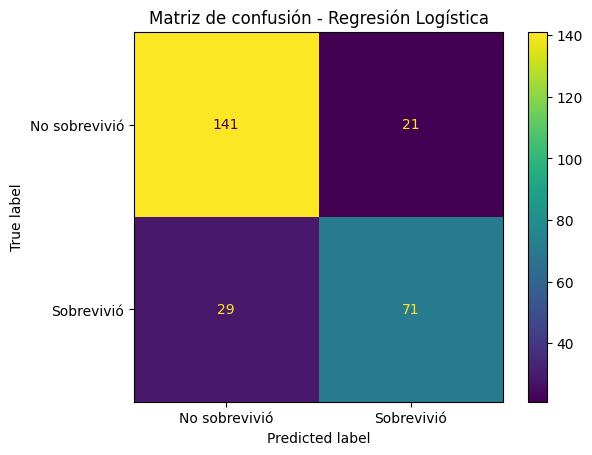

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=['No sobrevivió', 'Sobrevivió']
)

disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

## 26. Interpretación de los coeficientes y Odds Ratio del modelo

La Regresión Logística permite analizar la influencia de cada variable
predictora mediante sus coeficientes y Odds Ratio.

Un coeficiente positivo indica una relación positiva con las probabilidades
de supervivencia, mientras que un coeficiente negativo indica una relación
negativa.

El Odds Ratio (OR) se obtiene aplicando la función exponencial al coeficiente.
Un OR mayor que 1 indica un aumento de las odds de supervivencia, mientras
que un OR menor que 1 indica una disminución.

En este modelo, las variables numéricas fueron estandarizadas, por lo que
para `pclass`, `age`, `sibsp`, `parch` y `fare` el Odds Ratio representa el
cambio en las odds asociado a un aumento de una desviación estándar de la
variable.

Los resultados muestran que `sex_male` presenta el efecto negativo más
pronunciado, con un Odds Ratio de 0.0872, lo que indica que, manteniendo las
demás variables constantes, ser hombre se asocia con menores odds de
supervivencia respecto de la categoría de referencia femenina.

`pclass` presenta un Odds Ratio de 0.4747, indicando una disminución de las
odds de supervivencia ante un aumento de una desviación estándar en esta
variable.

Por otra parte, `fare` presenta un Odds Ratio de 1.0703, siendo la variable
numérica con efecto positivo más alto dentro del modelo. `parch` presenta
un efecto positivo muy pequeño, con un Odds Ratio de 1.0117.

Las variables `age`, `sibsp`, `embarked_S` y `embarked_Q` presentan Odds Ratio
menores que 1, indicando una asociación negativa con las odds de supervivencia
respecto de las condiciones de referencia correspondientes.

In [ ]:
import numpy as np

coeficientes = pd.DataFrame({
    'Variable': variables_modelo,
    'Coeficiente': modelo_logistico.coef_[0]
})

coeficientes['Odds Ratio'] = np.exp(coeficientes['Coeficiente'])

coeficientes = coeficientes.sort_values(
    'Odds Ratio',
    ascending=False
)

print("Coeficientes y Odds Ratio de la Regresión Logística:")
display(coeficientes.round(4))

Coeficientes y Odds Ratio de la Regresión Logística:


,Variable,Coeficiente,Odds Ratio
4,fare,0.0679,1.0703
3,parch,0.0116,1.0117
2,sibsp,-0.3104,0.7331
1,age,-0.4628,0.6295
7,embarked_S,-0.6435,0.5254
0,pclass,-0.7451,0.4747
6,embarked_Q,-0.7595,0.4679
5,sex_male,-2.4397,0.0872


## 27. Visualización de los coeficientes

Se representarán gráficamente los coeficientes de la Regresión Logística.

Los valores positivos representan una asociación positiva con la predicción de supervivencia, mientras que los valores negativos representan una asociación negativa.

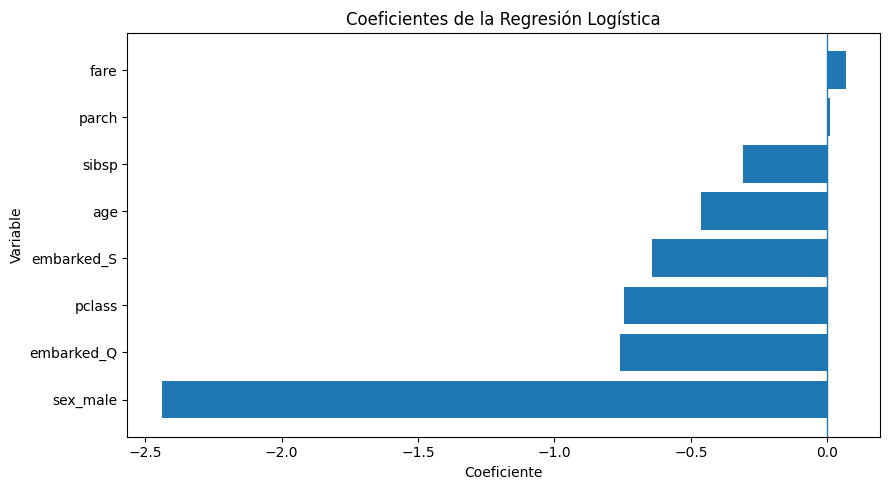

In [ ]:
coeficientes_ordenados = coeficientes.sort_values('Coeficiente')

plt.figure(figsize=(9, 5))

plt.barh(
    coeficientes_ordenados['Variable'],
    coeficientes_ordenados['Coeficiente']
)

plt.axvline(0, linewidth=1)
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.title('Coeficientes de la Regresión Logística')
plt.tight_layout()
plt.show()

## 28. Curva ROC y AUC

La curva ROC permite evaluar la capacidad del modelo para distinguir entre las dos clases de la variable objetivo.

El área bajo la curva (AUC) resume este desempeño:

- Un AUC cercano a 1 indica una excelente capacidad de discriminación.
- Un AUC cercano a 0.5 indica una capacidad similar al azar.

Para este análisis se utilizarán las probabilidades de supervivencia calculadas anteriormente.

AUC: 0.8680


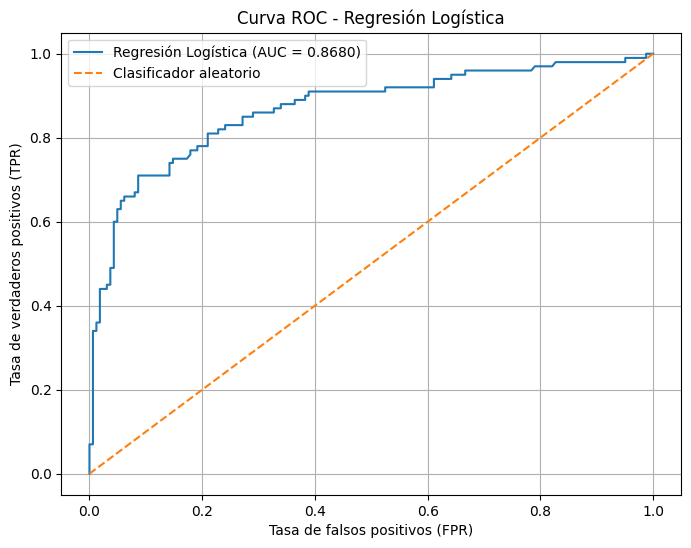

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test_eval,
    y_prob_log,
    pos_label='1'
)

auc = roc_auc_score(
    y_test_eval,
    y_prob_log
)

print(f"AUC: {auc:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Regresión Logística (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificador aleatorio'
)

plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid()
plt.show()

## 29. Entrenamiento del modelo Random Forest

Se entrenará un modelo Random Forest como segundo algoritmo de clasificación.

Random Forest está compuesto por múltiples árboles de decisión y permite modelar relaciones no lineales entre las variables predictoras.

A diferencia de la Regresión Logística, este algoritmo no requiere que las variables numéricas estén estandarizadas.

Se utilizará la misma división de entrenamiento y prueba empleada para la Regresión Logística, permitiendo realizar una comparación justa entre ambos modelos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## 30. Predicciones del modelo Random Forest

Se utilizará el modelo Random Forest entrenado para realizar predicciones sobre el conjunto de prueba.

Se obtendrán tanto las clases predichas como las probabilidades estimadas de supervivencia, las cuales serán utilizadas posteriormente para calcular las métricas de evaluación y la curva ROC.

In [ ]:
y_pred_rf = modelo_rf.predict(X_test)

y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Predicciones del Random Forest generadas correctamente.")

print("\nPrimeras 10 clases predichas:")
print(y_pred_rf[:10])

print("\nPrimeras 10 probabilidades de supervivencia:")
print(y_prob_rf[:10].round(4))

Predicciones del Random Forest generadas correctamente.

Primeras 10 clases predichas:
[1 1 0 0 0 0 0 0 1 0]

Primeras 10 probabilidades de supervivencia:
[0.6299 0.63   0.4365 0.2846 0.005  0.075  0.275  0.345  0.97   0.0183]


## 31. Evaluación del modelo Random Forest

Se evaluará el desempeño del Random Forest utilizando el mismo conjunto de prueba empleado para la Regresión Logística.

Se calcularán:

- Accuracy
- Precision
- Recall
- F1-score
- AUC

Esto permitirá realizar posteriormente una comparación directa entre ambos modelos.

In [ ]:
# Convertimos al mismo tipo utilizado en la evaluación anterior
y_pred_rf_eval = y_pred_rf.astype(str)

accuracy_rf = accuracy_score(y_test_eval, y_pred_rf_eval)
precision_rf = precision_score(y_test_eval, y_pred_rf_eval, pos_label='1')
recall_rf = recall_score(y_test_eval, y_pred_rf_eval, pos_label='1')
f1_rf = f1_score(y_test_eval, y_pred_rf_eval, pos_label='1')

auc_rf = roc_auc_score(
    y_test_eval,
    y_prob_rf
)

matriz_confusion_rf = confusion_matrix(
    y_test_eval,
    y_pred_rf_eval,
    labels=['0', '1']
)

print("MÉTRICAS DEL RANDOM FOREST")
print("=" * 40)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"AUC      : {auc_rf:.4f}")

print("\nMatriz de confusión:")
print(matriz_confusion_rf)

MÉTRICAS DEL RANDOM FOREST
Accuracy : 0.7901
Precision: 0.7273
Recall   : 0.7200
F1-score : 0.7236
AUC      : 0.8575

Matriz de confusión:
[[135  27]
 [ 28  72]]


### Interpretación de los resultados

El modelo Random Forest obtuvo un Accuracy de 0.7901, lo que indica que
clasificó correctamente aproximadamente el 79,01 % de los pasajeros del
conjunto de prueba.

El Precision de 0.7273 indica que, entre los pasajeros que el modelo predijo
como sobrevivientes, aproximadamente el 72,73 % efectivamente sobrevivió.
El Recall de 0.7200 indica que el modelo identificó correctamente el 72,00 %
de los pasajeros que realmente sobrevivieron.

El F1-score de 0.7236 muestra un equilibrio moderado entre Precision y Recall.
Por su parte, el AUC de 0.8575 indica una buena capacidad del modelo para
discriminar entre pasajeros sobrevivientes y no sobrevivientes.

La matriz de confusión permite observar los aciertos y errores de clasificación
de manera directa. En particular, el modelo presenta tanto falsos positivos
como falsos negativos, por lo que su desempeño debe analizarse considerando
el costo de ambos tipos de error en el contexto del problema.

## 32. Comparación de modelos

Se comparan los resultados obtenidos por la Regresión Logística y Random Forest utilizando el mismo conjunto de prueba.

El objetivo es determinar cuál de los dos modelos presenta un mejor desempeño general.

In [ ]:
resultados_modelos = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf],
    'Precision': [precision, precision_rf],
    'Recall': [recall, recall_rf],
    'F1-score': [f1, f1_rf],
    'AUC': [auc, auc_rf]
})

resultados_modelos = resultados_modelos.round(4)

display(resultados_modelos)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Regresión Logística,0.8092,0.7717,0.71,0.7396,0.8680
1,Random Forest,0.7901,0.7273,0.72,0.7236,0.8575


### Consideración metodológica de la comparación

En esta etapa se comparan la Regresión Logística y Random Forest utilizando
el mismo conjunto de prueba y las mismas métricas. Ambos modelos fueron
evaluados bajo condiciones equivalentes, por lo que sus resultados pueden
compararse directamente.

La Regresión Logística presenta un Accuracy de 0.8092, Precision de 0.7717,
Recall de 0.7100, F1-score de 0.7396 y AUC de 0.8680. Random Forest obtiene
un Accuracy de 0.7901, Precision de 0.7273, Recall de 0.7200,
F1-score de 0.7236 y AUC de 0.8575.

La Regresión Logística presenta mejores resultados en Accuracy, Precision,
F1-score y AUC, mientras que Random Forest obtiene un Recall ligeramente
superior. La comparación con la Red Neuronal se realizará posteriormente,
una vez completada su evaluación mediante validación cruzada y conjunto de
prueba.

## 33. Comparación gráfica de modelos

Se compararán gráficamente las métricas obtenidas por los dos modelos entrenados.

Esta visualización permitirá identificar de forma directa las diferencias de desempeño entre la Regresión Logística y Random Forest.

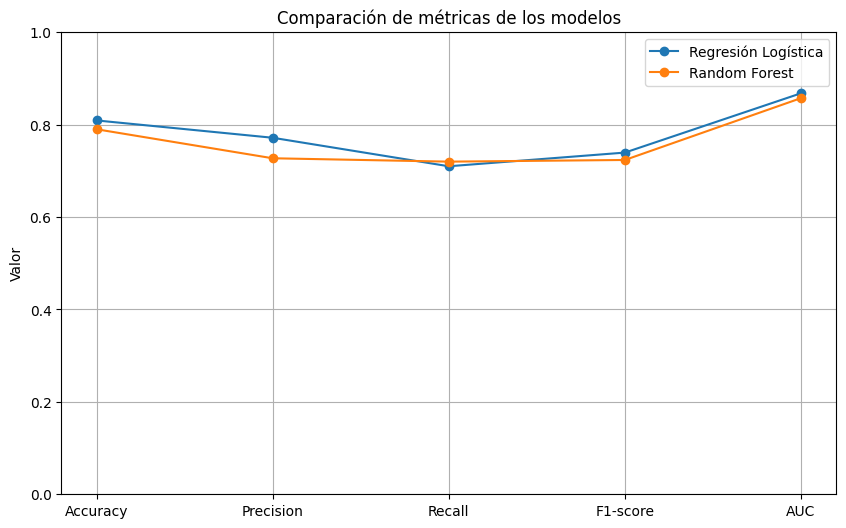

In [ ]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']

x = range(len(metricas))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    resultados_modelos.loc[0, metricas],
    marker='o',
    label='Regresión Logística'
)

plt.plot(
    x,
    resultados_modelos.loc[1, metricas],
    marker='o',
    label='Random Forest'
)

plt.xticks(x, metricas)
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.title('Comparación de métricas de los modelos')
plt.legend()
plt.grid()
plt.show()

### Interpretación de la comparación gráfica

La comparación gráfica permite observar que la Regresión Logística presenta un desempeño competitivo frente a Random Forest en las métricas evaluadas. La Regresión Logística obtiene mayores valores de Accuracy, Precision, F1-score y AUC, mientras que Random Forest presenta un Recall ligeramente superior.

Esta comparación corresponde a la evaluación inicial de ambos modelos sobre el mismo conjunto de prueba. Posteriormente, la Red Neuronal será incorporada a la comparación global utilizando las mismas métricas y el mismo conjunto de prueba, permitiendo determinar cuál de los tres modelos presenta el mejor desempeño general.

Por lo tanto, en esta etapa no se establece todavía el modelo final, ya que la selección debe considerar los resultados de los tres modelos evaluados.

## 34. Importancia de las variables — Random Forest

Random Forest permite estimar la importancia relativa de cada variable predictora
en la clasificación.

Esta información permite identificar qué variables contribuyen en mayor medida
a las decisiones del conjunto de árboles.

In [ ]:
importancias_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by='Importancia',
    ascending=False
)

display(importancias_rf.round(4))

,Variable,Importancia
4,fare,0.2895
1,age,0.2748
5,sex_male,0.2363
0,pclass,0.0732
2,sibsp,0.0499
3,parch,0.0433
7,embarked_S,0.0235
6,embarked_Q,0.0096


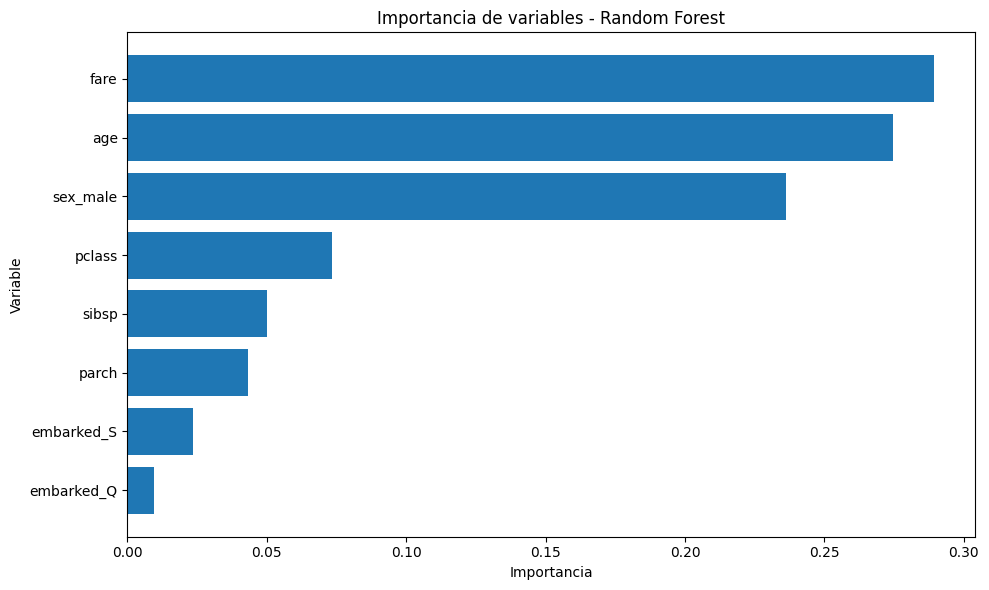

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importancias_rf['Variable'],
    importancias_rf['Importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de variables - Random Forest')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

Los resultados muestran que `fare`, `age` y `sex_male` son las variables con
mayor importancia dentro del modelo Random Forest, con valores de 0.2895,
0.2748 y 0.2363, respectivamente.

En conjunto, estas tres variables concentran la mayor parte de la importancia
predictiva del modelo. `pclass` presenta una importancia considerablemente
menor (0.0732), mientras que `sibsp`, `parch`, `embarked_S` y `embarked_Q`
presentan contribuciones relativamente menores.

Estos resultados permiten identificar los predictores que más contribuyen a
las decisiones del Random Forest. Sin embargo, la importancia de variables es
una medida de contribución predictiva dentro del modelo y no debe interpretarse
como evidencia de causalidad.


## 35. Comparación de curvas ROC

Se comparan las curvas ROC de la Regresión Logística y Random Forest
utilizando las probabilidades de predicción obtenidas sobre el conjunto
de prueba.

Esta comparación permite evaluar la capacidad de ambos modelos para
distinguir entre pasajeros que sobrevivieron y aquellos que no sobrevivieron.

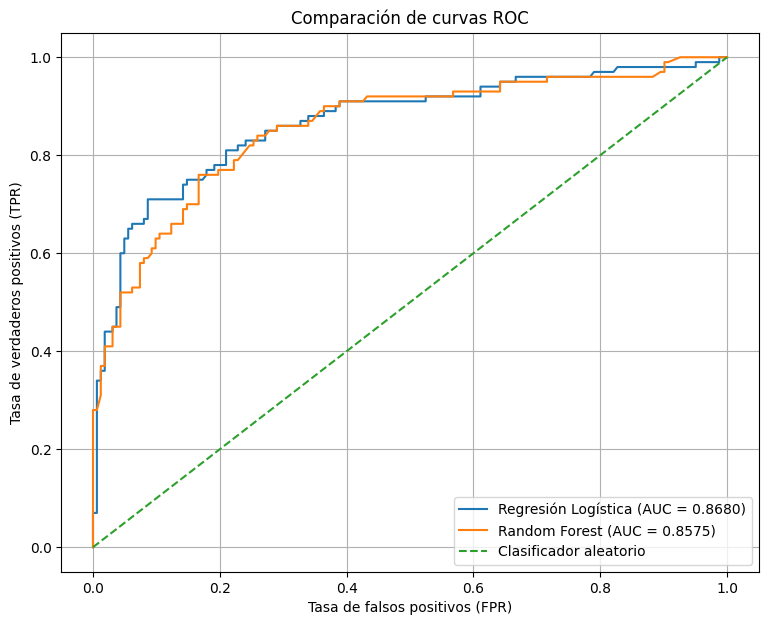

In [ ]:
from sklearn.metrics import roc_curve

# Curva ROC de Regresión Logística
fpr_log, tpr_log, _ = roc_curve(
    y_test_eval,
    y_prob_log,
    pos_label='1'
)

# Curva ROC de Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_eval,
    y_prob_rf,
    pos_label='1'
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Regresión Logística (AUC = {auc:.4f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Comparación de curvas ROC')
plt.legend()
plt.grid()
plt.show()

### Interpretación de las curvas ROC

La curva ROC permite comparar la capacidad de los modelos para distinguir entre pasajeros que sobrevivieron y aquellos que no sobrevivieron para distintos umbrales de clasificación.

La Regresión Logística presenta un AUC de 0.8680, mientras que Random Forest alcanza un AUC de 0.8575. Ambos valores indican una buena capacidad discriminativa, aunque la Regresión Logística obtiene un desempeño ligeramente superior.

La diferencia entre ambos AUC es pequeña (0.0105), por lo que los dos modelos presentan una capacidad de discriminación similar. Sin embargo, considerando el conjunto de métricas evaluadas anteriormente, la Regresión Logística mantiene una ventaja en Accuracy, Precision y F1-score, mientras que Random Forest presenta un Recall ligeramente superior.

Esta comparación corresponde a los dos modelos analizados inicialmente. La Red Neuronal se incorpora posteriormente en la comparación global y en la selección del modelo final, considerando sus resultados obtenidos sobre el mismo conjunto de prueba.

## 36. Validación y estabilidad de la Red Neuronal

Con el objetivo de analizar la estabilidad del desempeño de la Red Neuronal, se realiza una validación cruzada estratificada mediante Stratified K-Fold con 5 particiones. Esta técnica permite evaluar el comportamiento del modelo utilizando diferentes particiones del conjunto de entrenamiento, manteniendo en cada fold una proporción similar de las clases de la variable objetivo.

El propósito de esta etapa es complementar la evaluación realizada sobre el conjunto de prueba y analizar si el desempeño de la Red Neuronal presenta un comportamiento consistente al modificar la partición utilizada para entrenamiento y validación.

La validación considera las métricas Accuracy, Precision, Recall, F1-score y AUC, registrando los resultados obtenidos en cada fold y calculando posteriormente su media y desviación estándar.

## 37. Validación cruzada de una Red Neuronal

Para complementar la evaluación de los modelos anteriores, se implementa una
Red Neuronal Artificial para clasificación con una sola capa oculta.

La validación se realizará mediante Stratified K-Fold con 5 particiones,
manteniendo aproximadamente la misma proporción de las clases `survived` en
cada fold.

La red neuronal tendrá una única capa oculta y se evaluará mediante Accuracy,
Precision, Recall, F1-score y ROC-AUC.

A diferencia de una evaluación Hold-Out, la validación cruzada permite obtener
resultados sobre múltiples particiones del conjunto de entrenamiento,
permitiendo analizar tanto el desempeño promedio como la variabilidad de las
métricas.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Red Neuronal con una sola capa oculta
red_neuronal = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(16,),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    ))
])

print("Red Neuronal configurada correctamente.")
print("Arquitectura: 8 variables de entrada -> 16 neuronas -> salida binaria")
print("Número de capas ocultas: 1")

Red Neuronal configurada correctamente.
Arquitectura: 8 variables de entrada -> 16 neuronas -> salida binaria
Número de capas ocultas: 1


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Convertimos la variable objetivo a entero para asegurar
# compatibilidad con las métricas de clasificación
y_train_cv = y_train.astype(int)

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Métricas de evaluación
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    'recall': make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),
    'f1': make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),
    'roc_auc': 'roc_auc'
}

# Validación cruzada de la Red Neuronal
cv_resultados = cross_validate(
    red_neuronal,
    X_train,
    y_train_cv,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Resultados por fold
resultados_folds = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_resultados['test_accuracy'],
    'Precision': cv_resultados['test_precision'],
    'Recall': cv_resultados['test_recall'],
    'F1-score': cv_resultados['test_f1'],
    'AUC': cv_resultados['test_roc_auc']
})

print("RESULTADOS POR FOLD - RED NEURONAL")
print("=" * 60)

display(resultados_folds.round(4))

# Resumen de resultados
resultados_cv = pd.DataFrame({
    'Métrica': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'AUC'
    ],
    'Media': [
        cv_resultados['test_accuracy'].mean(),
        cv_resultados['test_precision'].mean(),
        cv_resultados['test_recall'].mean(),
        cv_resultados['test_f1'].mean(),
        cv_resultados['test_roc_auc'].mean()
    ],
    'Desviación estándar': [
        cv_resultados['test_accuracy'].std(),
        cv_resultados['test_precision'].std(),
        cv_resultados['test_recall'].std(),
        cv_resultados['test_f1'].std(),
        cv_resultados['test_roc_auc'].std()
    ]
})

print("\nVALIDACIÓN CRUZADA - RED NEURONAL")
print("=" * 60)

display(resultados_cv.round(4))

RESULTADOS POR FOLD - RED NEURONAL


,Fold,Accuracy,Precision,Recall,F1-score,AUC
0,1,0.7905,0.7500,0.6750,0.7105,0.8401
1,2,0.7810,0.7833,0.5875,0.6714,0.8541
2,3,0.8086,0.7439,0.7625,0.7531,0.8630
3,4,0.7990,0.8393,0.5875,0.6912,0.8295
4,5,0.7703,0.8077,0.5250,0.6364,0.8660



VALIDACIÓN CRUZADA - RED NEURONAL


,Métrica,Media,Desviación estándar
0,Accuracy,0.7899,0.0134
1,Precision,0.7848,0.0357
2,Recall,0.6275,0.0827
3,F1-score,0.6925,0.0390
4,AUC,0.8506,0.0139


### Interpretación y justificación de la validación cruzada

Se utilizó Stratified K-Fold con 5 particiones debido al tamaño del dataset, que contiene 1.309 registros, de los cuales 1.047 corresponden al conjunto de entrenamiento. Esta técnica mantiene aproximadamente la proporción de las clases `survived` en cada fold y permite observar el desempeño del modelo en múltiples particiones.

La elección de 5 folds representa un compromiso adecuado entre estabilidad y costo computacional. En cada iteración se utiliza aproximadamente el 80 % del conjunto de entrenamiento para ajustar el modelo y el 20 % restante para validarlo. Esto requiere cinco entrenamientos, mientras que Leave-One-Out implicaría aproximadamente 1.047 entrenamientos.

Los resultados obtenidos fueron:

- Accuracy: **0.7899 ± 0.0134**
- Precision: **0.7848 ± 0.0357**
- Recall: **0.6275 ± 0.0827**
- F1-score: **0.6925 ± 0.0390**
- AUC: **0.8506 ± 0.0139**

Accuracy y AUC presentan las menores desviaciones estándar, por lo que muestran un comportamiento relativamente estable entre los folds. Recall presenta la mayor variabilidad, con valores entre 0.5250 y 0.7625, por lo que constituye la principal dimensión de mejora del modelo.

**Precaución metodológica:** el conjunto de prueba no interviene en la validación cruzada. Sin embargo, en este notebook la imputación, codificación y un primer escalamiento se realizaron antes de `cross_validate`. Una versión metodológicamente más estricta debería encapsular todas las transformaciones que aprenden parámetros dentro de cada fold mediante un `Pipeline`/`ColumnTransformer`, tal como recomienda el material de la Fase 4 para evitar filtración de información entre entrenamiento y validación interna.


### Evaluación de la Red Neuronal en el conjunto de prueba

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Entrenar la red neuronal con todo el conjunto de entrenamiento
red_neuronal.fit(X_train, y_train.astype(int))

# Predicciones sobre el conjunto de prueba
y_pred_nn = red_neuronal.predict(X_test)
y_prob_nn = red_neuronal.predict_proba(X_test)[:, 1]

# Métricas sobre el conjunto de prueba
accuracy_nn_test = accuracy_score(y_test.astype(int), y_pred_nn)
precision_nn_test = precision_score(
    y_test.astype(int),
    y_pred_nn,
    pos_label=1,
    zero_division=0
)
recall_nn_test = recall_score(
    y_test.astype(int),
    y_pred_nn,
    pos_label=1,
    zero_division=0
)
f1_nn_test = f1_score(
    y_test.astype(int),
    y_pred_nn,
    pos_label=1,
    zero_division=0
)
auc_nn_test = roc_auc_score(
    y_test.astype(int),
    y_prob_nn
)

print("MÉTRICAS RED NEURONAL - CONJUNTO DE PRUEBA")
print("=" * 50)
print(f"Accuracy : {accuracy_nn_test:.4f}")
print(f"Precision: {precision_nn_test:.4f}")
print(f"Recall   : {recall_nn_test:.4f}")
print(f"F1-score : {f1_nn_test:.4f}")
print(f"AUC      : {auc_nn_test:.4f}")

MÉTRICAS RED NEURONAL - CONJUNTO DE PRUEBA
Accuracy : 0.8397
Precision: 0.8295
Recall   : 0.7300
F1-score : 0.7766
AUC      : 0.8711


### Matriz de confusión de la Red Neuronal

La matriz de confusión permite identificar los aciertos y errores de
clasificación de la Red Neuronal sobre el conjunto de prueba.

La clase positiva corresponde a `survived = 1`, es decir, pasajeros que
sobrevivieron.

Matriz de confusión - Red Neuronal
[[147  15]
 [ 27  73]]


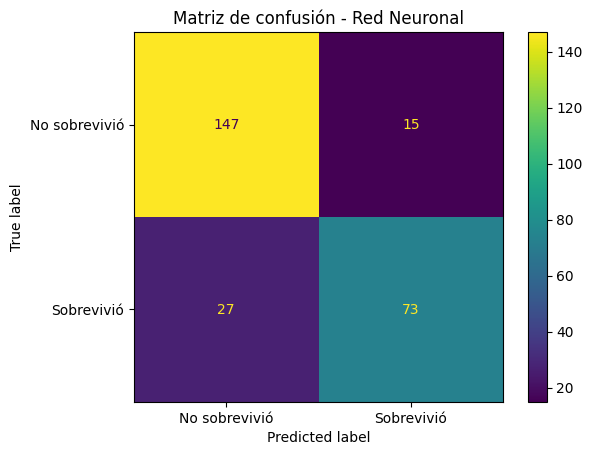

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz_confusion_nn = confusion_matrix(
    y_test.astype(int),
    y_pred_nn,
    labels=[0, 1]
)

print("Matriz de confusión - Red Neuronal")
print(matriz_confusion_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_nn,
    display_labels=['No sobrevivió', 'Sobrevivió']
)

disp.plot()
plt.title("Matriz de confusión - Red Neuronal")
plt.show()

## Comparación de los modelos

Se comparan los resultados obtenidos por los tres modelos de clasificación sobre el mismo conjunto de prueba: Regresión Logística, Random Forest y Red Neuronal.

Para asegurar una comparación directa del desempeño predictivo, se utilizan las métricas Accuracy, Precision, Recall, F1-score y AUC calculadas sobre el conjunto de prueba. La validación cruzada de la Red Neuronal se analiza adicionalmente para evaluar la estabilidad de su desempeño entre diferentes particiones de los datos.

Esta comparación permite identificar las fortalezas y limitaciones de cada modelo y fundamentar la selección del modelo final.

In [ ]:
resultados_comparacion = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest',
        'Red Neuronal'
    ],
    'Evaluación': [
        'Conjunto de prueba',
        'Conjunto de prueba',
        'Conjunto de prueba'
    ],
    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_nn_test
    ],
    'Precision': [
        precision,
        precision_rf,
        precision_nn_test
    ],
    'Recall': [
        recall,
        recall_rf,
        recall_nn_test
    ],
    'F1-score': [
        f1,
        f1_rf,
        f1_nn_test
    ],
    'AUC': [
        auc,
        auc_rf,
        auc_nn_test
    ]
})

print("COMPARACIÓN DE LOS MODELOS")
print("=" * 60)

display(
    resultados_comparacion.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-score': '{:.4f}',
        'AUC': '{:.4f}'
    })
)

COMPARACIÓN DE LOS MODELOS


,Modelo,Evaluación,Accuracy,Precision,Recall,F1-score,AUC
0,Regresión Logística,Conjunto de prueba,0.8092,0.7717,0.7100,0.7396,0.8680
1,Random Forest,Conjunto de prueba,0.7901,0.7273,0.7200,0.7236,0.8575
2,Red Neuronal,Conjunto de prueba,0.8397,0.8295,0.7300,0.7766,0.8711


## Interpretación de la comparación

Los resultados obtenidos sobre el conjunto de prueba muestran que la Red Neuronal presentó el mejor desempeño global entre los tres modelos evaluados. Alcanzó un Accuracy de 0.8397, Precision de 0.8295, Recall de 0.7300, F1-score de 0.7766 y AUC de 0.8711.

La Regresión Logística obtuvo un Accuracy de 0.8092, Precision de 0.7717, Recall de 0.7100, F1-score de 0.7396 y AUC de 0.8680. Por su parte, Random Forest alcanzó un Accuracy de 0.7901, Precision de 0.7273, Recall de 0.7200, F1-score de 0.7236 y AUC de 0.8575.

La Red Neuronal superó a los otros modelos en las cinco métricas evaluadas sobre el conjunto de prueba. Su principal fortaleza es el equilibrio entre Precision, Recall y F1-score, además de presentar el mayor AUC, lo que indica una buena capacidad de discriminación entre pasajeros que sobrevivieron y aquellos que no sobrevivieron.

Como complemento, la validación cruzada de la Red Neuronal presentó un Accuracy promedio de 0.7899 ± 0.0134 y un AUC promedio de 0.8506 ± 0.0139. Las desviaciones estándar reducidas de estas métricas indican un comportamiento relativamente estable entre las particiones. El Recall presentó un promedio de 0.6275 ± 0.0827, siendo la métrica con mayor variabilidad entre los folds.

En conjunto, los resultados del conjunto de prueba y la validación cruzada muestran que la Red Neuronal presenta el mejor desempeño predictivo global, aunque la variabilidad observada en Recall constituye una limitación que debe considerarse en futuras mejoras.

## 38. Selección del modelo final

A partir de los resultados obtenidos, se compararon tres modelos de clasificación: Regresión Logística, Random Forest y Red Neuronal.

La comparación sobre el conjunto de prueba muestra que la Red Neuronal obtuvo el mejor desempeño en todas las métricas consideradas, alcanzando un Accuracy de 0.8397, Precision de 0.8295, Recall de 0.7300, F1-score de 0.7766 y AUC de 0.8711.

La Regresión Logística presentó un desempeño inferior, aunque obtuvo resultados competitivos con un Accuracy de 0.8092 y un AUC de 0.8680. Random Forest alcanzó un Recall de 0.7200, ligeramente inferior al de la Red Neuronal, pero presentó menores valores en Accuracy, Precision, F1-score y AUC.

Adicionalmente, la validación cruzada de la Red Neuronal mostró un desempeño relativamente estable en Accuracy y AUC, con un Accuracy promedio de 0.7899 ± 0.0134 y un AUC promedio de 0.8506 ± 0.0139. El Recall presentó un promedio de 0.6275 ± 0.0827, mostrando una mayor variabilidad entre las particiones.

Considerando el mejor desempeño obtenido sobre el conjunto de prueba en las métricas evaluadas, junto con el comportamiento relativamente estable observado en Accuracy y AUC durante la validación cruzada, se selecciona la Red Neuronal como modelo final para la predicción de supervivencia. La mayor variabilidad observada en Recall constituye una limitación que deberá considerarse en futuras mejoras del modelo.

In [ ]:
# Selección del modelo final

modelo_final = 'Red Neuronal'

print("MODELO FINAL SELECCIONADO")
print("=" * 40)
print(f"Modelo    : {modelo_final}")
print(f"Accuracy  : {accuracy_nn_test:.4f}")
print(f"Precision : {precision_nn_test:.4f}")
print(f"Recall    : {recall_nn_test:.4f}")
print(f"F1-score  : {f1_nn_test:.4f}")
print(f"AUC       : {auc_nn_test:.4f}")

MODELO FINAL SELECCIONADO
Modelo    : Red Neuronal
Accuracy  : 0.8397
Precision : 0.8295
Recall    : 0.7300
F1-score  : 0.7766
AUC       : 0.8711


## 39. Interpretación y análisis final

Se evaluaron tres modelos de clasificación para predecir la supervivencia de los pasajeros: Regresión Logística, Random Forest y Red Neuronal.

La Red Neuronal presentó el mejor desempeño sobre el conjunto de prueba, con un Accuracy de 0.8397, Precision de 0.8295, Recall de 0.7300, F1-score de 0.7766 y AUC de 0.8711. Estos resultados indican que el modelo logró el mejor equilibrio entre capacidad de clasificación, identificación de sobrevivientes y discriminación entre las dos clases.

La Regresión Logística alcanzó un Accuracy de 0.8092 y un AUC de 0.8680, mostrando también un desempeño competitivo. Además, presenta la ventaja de una mayor interpretabilidad, ya que sus coeficientes y Odds Ratio permiten analizar directamente la relación entre las variables predictoras y la probabilidad estimada de supervivencia.

Random Forest obtuvo un Recall de 0.7200, ligeramente inferior al de la Red Neuronal, pero presentó menores valores de Accuracy, Precision, F1-score y AUC.

La validación cruzada de la Red Neuronal mostró un comportamiento relativamente estable en Accuracy y AUC, aunque el Recall presentó una mayor variabilidad entre las particiones. Esta consideración constituye una limitación del modelo, pero no modifica su posición como la alternativa con mejor desempeño global en el conjunto de prueba.

En consecuencia, se selecciona la Red Neuronal como modelo final debido a que obtuvo el mejor desempeño global sobre el conjunto de prueba. La validación cruzada complementa esta evaluación mostrando un comportamiento relativamente estable en Accuracy y AUC, aunque el Recall presenta una mayor variabilidad entre las particiones.

## 40. Conclusión general

El desarrollo permitió construir y evaluar modelos de clasificación para predecir la supervivencia de pasajeros del Titanic a partir de variables disponibles antes del evento, considerando características demográficas, socioeconómicas y relacionadas con el viaje.

Durante el proceso se realizó la exploración del dataset, identificación de la variable objetivo, análisis de valores faltantes y cardinalidad, exclusión de variables asociadas a posible fuga de información, imputación de datos faltantes, codificación de variables categóricas, división estratificada de los datos en entrenamiento y prueba y escalamiento de las variables numéricas.

Posteriormente se implementaron y evaluaron tres modelos de clasificación: Regresión Logística, Random Forest y Red Neuronal. La comparación sobre el conjunto de prueba mostró que la Red Neuronal obtuvo el mejor desempeño en las métricas consideradas, alcanzando un Accuracy de 0.8397, Precision de 0.8295, Recall de 0.7300, F1-score de 0.7766 y AUC de 0.8711.

La validación cruzada de la Red Neuronal permitió complementar la evaluación del conjunto de prueba, obteniendo un Accuracy promedio de 0.7899 ± 0.0134 y un AUC promedio de 0.8506 ± 0.0139. Las bajas desviaciones estándar de Accuracy y AUC indican un comportamiento relativamente estable entre las particiones. El Recall presentó un promedio de 0.6275 ± 0.0827, con una variabilidad mayor entre los folds, por lo que constituye una métrica relevante para evaluar posibles mejoras futuras.

En consecuencia, se seleccionó la Red Neuronal como modelo final por presentar el mejor desempeño global sobre el conjunto de prueba. La validación cruzada mostró un comportamiento relativamente estable en Accuracy y AUC, mientras que el Recall presentó una mayor variabilidad entre las particiones, constituyendo una oportunidad de mejora para aumentar la capacidad del modelo de identificar correctamente los casos positivos.

## 41. Resumen final de resultados

| Modelo | Evaluación | Accuracy | Precision | Recall | F1-score | AUC |
|---|---|---:|---:|---:|---:|---:|
| Regresión Logística | Conjunto de prueba | 0.8092 | 0.7717 | 0.7100 | 0.7396 | 0.8680 |
| Random Forest | Conjunto de prueba | 0.7901 | 0.7273 | 0.7200 | 0.7236 | 0.8575 |
| **Red Neuronal** | **Conjunto de prueba** | **0.8397** | **0.8295** | **0.7300** | **0.7766** | **0.8711** |

### Modelo seleccionado

**Red Neuronal**

- Accuracy: **0.8397**
- Precision: **0.8295**
- Recall: **0.7300**
- F1-score: **0.7766**
- AUC: **0.8711**

La Red Neuronal fue seleccionada como modelo final por presentar el mejor desempeño global sobre el conjunto de prueba. La validación cruzada mostró un comportamiento relativamente estable en Accuracy y AUC, mientras que el Recall presentó una mayor variabilidad entre las particiones.

In [ ]:
# Resumen final del proyecto

print("=" * 60)
print("RESUMEN FINAL DEL PROYECTO")
print("=" * 60)

print("\nVariable objetivo:")
print("survived")

print("\nVariables predictoras utilizadas:")
for i, variable in enumerate(X_train.columns, 1):
    print(f"{i}. {variable}")

print("\nModelos evaluados:")
print("1. Regresión Logística")
print("2. Random Forest")
print("3. Red Neuronal")

print("\nResultados de los modelos:")
display(resultados_comparacion.round(4))

print("\nModelo seleccionado:")
print("Red Neuronal")

print("\nMétricas del modelo final:")
print("Accuracy  : 0.8397")
print("Precision : 0.8295")
print("Recall    : 0.7300")
print("F1-score  : 0.7766")
print("AUC       : 0.8711")

RESUMEN FINAL DEL PROYECTO

Variable objetivo:
survived

Variables predictoras utilizadas:
1. pclass
2. age
3. sibsp
4. parch
5. fare
6. sex_male
7. embarked_Q
8. embarked_S

Modelos evaluados:
1. Regresión Logística
2. Random Forest
3. Red Neuronal

Resultados de los modelos:


,Modelo,Evaluación,Accuracy,Precision,Recall,F1-score,AUC
0,Regresión Logística,Conjunto de prueba,0.8092,0.7717,0.71,0.7396,0.8680
1,Random Forest,Conjunto de prueba,0.7901,0.7273,0.72,0.7236,0.8575
2,Red Neuronal,Conjunto de prueba,0.8397,0.8295,0.73,0.7766,0.8711



Modelo seleccionado:
Red Neuronal

Métricas del modelo final:
Accuracy  : 0.8397
Precision : 0.8295
Recall    : 0.7300
F1-score  : 0.7766
AUC       : 0.8711


## 42. Síntesis de los principales hallazgos

### Datos y preparación

El dataset contiene 1.309 registros y se utilizó `survived` como variable
objetivo. Después del análisis de las variables, los valores faltantes y
la posible fuga de información, se seleccionaron inicialmente siete
variables predictoras:

- `pclass`
- `sex`
- `age`
- `sibsp`
- `parch`
- `fare`
- `embarked`

Las variables categóricas fueron transformadas mediante variables dummy,
obteniendo finalmente ocho variables predictoras para los modelos:

- `pclass`
- `age`
- `sibsp`
- `parch`
- `fare`
- `sex_male`
- `embarked_Q`
- `embarked_S`

Las variables numéricas fueron escaladas utilizando únicamente la
información correspondiente al conjunto de entrenamiento.

### Modelamiento

Se evaluaron tres algoritmos de clasificación:

- Regresión Logística
- Random Forest
- Red Neuronal

La Red Neuronal fue evaluada mediante validación cruzada estratificada de
5 folds para analizar la estabilidad de sus métricas. Posteriormente, los
tres modelos fueron evaluados y comparados sobre el mismo conjunto de prueba.

### Resultado

La Red Neuronal obtuvo el mejor desempeño general sobre el conjunto de
prueba:

- **Accuracy:** 83,97 %
- **Precision:** 82,95 %
- **Recall:** 73,00 %
- **F1-score:** 77,66 %
- **AUC:** 87,11 %

La Regresión Logística obtuvo un Accuracy de 80,92 % y un AUC de 86,80 %,
mientras que Random Forest obtuvo un Accuracy de 79,01 % y un AUC de
85,75 %.

Aunque Random Forest presentó un Recall de 72,00 %, ligeramente inferior
al 73,00 % de la Red Neuronal, la Red Neuronal obtuvo mejores resultados
en Accuracy, Precision, F1-score y AUC.

Por lo tanto, considerando el desempeño conjunto de las métricas
evaluadas, la **Red Neuronal fue seleccionada como modelo final**.

### Variables relevantes

El análisis de los coeficientes de la Regresión Logística mostró que
`sex_male` presentó el coeficiente de mayor magnitud absoluta, con un
valor de -2,4397 y un Odds Ratio de 0,0872.

Por su parte, el análisis de importancia de variables del Random Forest
identificó como las tres variables más importantes a:

1. `fare` — 0,2895
2. `age` — 0,2748
3. `sex_male` — 0,2363

Estos análisis permiten complementar la evaluación del desempeño
predictivo con una interpretación de las variables utilizadas por los
modelos. En particular, `sex_male` aparece como una variable relevante
tanto en la interpretación de la Regresión Logística como en la
importancia estimada por Random Forest.


## 43. Conclusión final

El desarrollo del proyecto permitió construir y evaluar distintos modelos
de clasificación para predecir la supervivencia de los pasajeros del
Titanic. A partir del análisis exploratorio y del tratamiento de los datos,
se seleccionaron variables predictoras relevantes, se trataron los valores
faltantes, se codificaron las variables categóricas y se escalaron las
variables numéricas utilizando la información del conjunto de entrenamiento.

Se implementaron y compararon tres modelos de clasificación: Regresión Logística, Random Forest y Red Neuronal. La evaluación sobre el conjunto de prueba permitió comparar los tres modelos mediante Accuracy, Precision, Recall, F1-score y AUC. Adicionalmente, se aplicó validación cruzada estratificada a la Red Neuronal, con el propósito de analizar la estabilidad de sus métricas entre diferentes particiones del conjunto de entrenamiento.

Los resultados obtenidos muestran que la Red Neuronal presentó el mejor
desempeño general sobre el conjunto de prueba, alcanzando un Accuracy de
83,97 %, Precision de 82,95 %, Recall de 73,00 %, F1-score de 77,66 % y
AUC de 87,11 %. Por este motivo, fue seleccionada como el modelo final del
proyecto.

El análisis de importancia de variables realizado sobre los modelos también
permitió identificar factores relevantes para la predicción. En particular,
la variable `sex_male` mostró una asociación importante en la Regresión
Logística, mientras que `fare`, `age` y `sex_male` destacaron entre las
variables de mayor importancia en Random Forest.

En conclusión, el proyecto permitió aplicar un flujo completo de aprendizaje
supervisado, desde la preparación y selección de variables hasta la
validación, comparación e interpretación de modelos. Los resultados
obtenidos respaldan la selección de la Red Neuronal como modelo final,
considerando su desempeño global en las métricas evaluadas.